In [1]:
# 数据增强
# 增加一个已有数据集, 使得有更多的多样性
#   - 在语言里加入各种不同的背景噪音
#   - 改变图片的形状和颜色, 或者截取

# 使用增强数据训练
# 原始数据 -> (在线生成) -> 增强后的数据 -> 进入模型训练

# 翻转 (左右, 上下翻转 -> 不总行, 取决于数据集的样子)
# 切割, 从图片中切割一块出来, 然后变成固定形状, 从原图中，
#   - 随机高宽比(3/4, 4/3)
#   - 随机大小(8%, 100%)
#   - 随机位置
# 颜色, 改变色调, 饱和度, 明亮度

# 总结
#  - 数据增强通过变形数据来获取多样性, 从而使得模型泛化性能更好
#  - 常见图片增广包括翻转, 切割, 变色

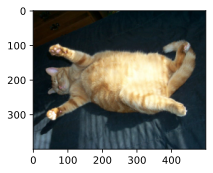

In [3]:
%matplotlib inline
import torch
import torchvision
from torch import nn
from d2l import torch as d2l

d2l.set_figsize()
img = d2l.Image.open('/Users/xinghaozhou/Desktop/DL/d2l-zh/pytorch/img/cat1.jpg')
d2l.plt.imshow(img)

In [4]:
def apply(img, aug, num_rows=2, num_cols=4, scale=1.5):
    Y = [aug(img) for _ in range(num_rows * num_cols)] # 对这张图片重复作用多少次
    d2l.show_images(Y, num_rows, num_cols, scale=scale)

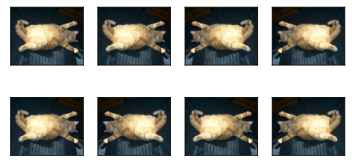

In [5]:
# 左右翻转
apply(img, torchvision.transforms.RandomHorizontalFlip())

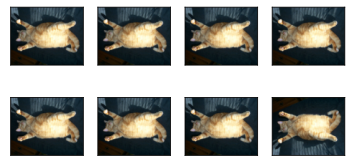

In [6]:
# 上下翻转
apply(img, torchvision.transforms.RandomVerticalFlip())

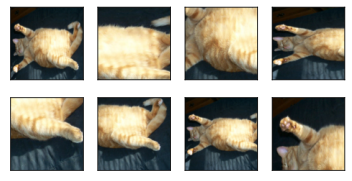

In [9]:
# 随机裁剪
shape_aug = torchvision.transforms.RandomResizedCrop(
    (200, 200), scale=(0.1, 1), ratio=(0.5, 2)) #这里的scale是裁剪原图的大小, ratio是高宽比
apply(img, shape_aug)

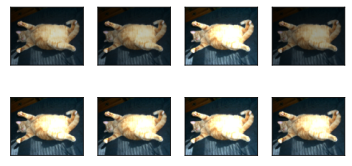

In [10]:
# 随机更改图像的亮度
apply(img, torchvision.transforms.ColorJitter(
    brightness=0.5, contrast=0, saturation=0, hue=0))

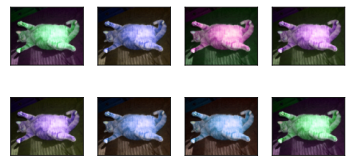

In [12]:
# 随机改变图像的色调
apply(img, torchvision.transforms.ColorJitter(
    brightness=0, contrast=0, saturation=0, hue=0.5))

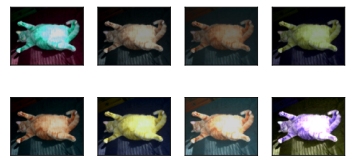

In [14]:
# 随机改变所有的参数
color_aug = torchvision.transforms.ColorJitter(
    brightness=0.5, contrast=0.5, saturation=0.5, hue=0.5)
apply(img, color_aug)

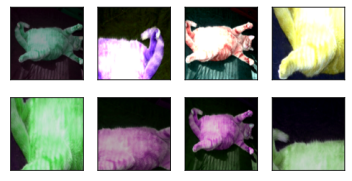

In [17]:
# 结合多种图像增广方法
augs = torchvision.transforms.Compose([
    torchvision.transforms.RandomHorizontalFlip(),
    color_aug, shape_aug])
apply(img, augs)

100.0%


Extracting ../data/cifar-10-python.tar.gz to ../data


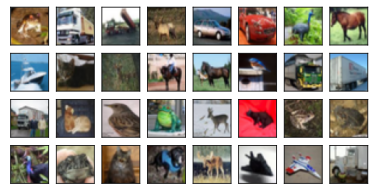

In [18]:
# 使用图像增广进行训练
all_images = torchvision.datasets.CIFAR10(
    train=True, root="../data", download=True)
d2l.show_images([
    all_images[i][0] for i in range(32)], 4, 8, scale=0.8);

In [19]:
# 只使用最简单的随机左右翻转
train_augs = torchvision.transforms.Compose([
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.ToTensor()])
test_augs = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor()])

In [20]:
# 定义一个辅助函数, 以便于读取图像和应用图像增广
def load_cifar10(is_train, augs, batch_size):
    dataset = torchvision.datasets.CIFAR10(
        root="../data", train=is_train,
        transform=augs, download=True)
    dataloader = torch.utils.data.DataLoader(
        dataset, batch_size=batch_size, shuffle=is_train,
        num_workers=d2l.get_dataloader_workers())
    return dataloader

In [22]:
# 定义一个函数, 使用多GPU对模型进行训练和评估
def train_batch_ch13(net, X, y, loss, trainer, devices):
    if isinstance(X, list):
        X = [x.to(devices[0]) for x in X]
    else:
        X = X.to(devices[0])
    y = y.to(devices[0])
    net.train()
    trainer.zero_grad()
    pred = net(X)
    l = loss(pred, y)
    l.sum().backward()
    trainer.step()
    train_loss_sum = l.sum()
    train_acc_sum = d2l.accurracy(pred, y)
    return train_loss_sum, train_acc_sum

def train_ch13(net, train_iter, test_iter, loss, trainer, num_epochs,
               devices=d2l.try_all_gpus(), split_f=d2l.split_batch):
    """用多GPU进行模型训练"""
    timer, num_batches = d2l.Timer(), len(train_iter)
    animator = d2l.Animator(xlabel='epoch', xlim=[1, num_epochs], ylim=[0, 1],
                            legend=['train loss', 'train acc', 'test acc'])
    for epoch in range(num_epochs):
        # 4个维度：储存训练损失，训练准确度，实例数，特点数
        metric = d2l.Accumulator(4)
        for i, (features, labels) in enumerate(train_iter):
            timer.start()
            l, acc = train_batch_ch13(
                net, features, labels, loss, trainer, devices, split_f)
            metric.add(l, acc, labels.shape[0], labels.size)
            timer.stop()
            if (i + 1) % (num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches,
                             (metric[0] / metric[2], metric[1] / metric[3],
                              None))
        test_acc = d2l.evaluate_accuracy_gpus(net, test_iter, split_f)
        animator.add(epoch + 1, (None, None, test_acc))
    print(f'loss {metric[0] / metric[2]:.3f}, train acc '
          f'{metric[1] / metric[3]:.3f}, test acc {test_acc:.3f}')
    print(f'{metric[2] * num_epochs / timer.sum():.1f} examples/sec on '
          f'{str(devices)}')

In [23]:
# 定义 train_with_data_aug函数, 使用图像增广来训练模型
batch_size, devices, net = 256, d2l.try_all_gpus(), d2l.resnet18(10)

def init_weights(m):
    if type(m) in [nn.Linear, nn.Conv2d]:
        nn.init.xavier_uniform_(m.weight)
net.apply(init_weights)

def train_with_data_aug(train_augs, test_augs, net, lr=0.001):
    train_iter = load_cifar10(True, train_augs, batch_size)
    test_iter = load_cifar10(False, test_augs, batch_size)
    loss = nn.CrossEntropyLoss(reduction="none")
    trainer = torch.optim.Adam(net.parameters(), lr=lr)
    train_ch13(net, train_iter, test_iter, loss, trainer, 10, devices)

In [ ]:
# 训练模型
train_with_data_aug(train_augs, test_augs, net)